# mjo_phase_background

- Plot background for MJO phase-space diagrams
- [NCL: mjo_phase_background](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_phase_background.shtml)

[NCL OUTPUT](mjo_phase_background.ncl) with different radii:
<table>
  <tr>
    <td><img src="mjo_output/mjo_phase_background_radius_1.png" width="500" height="300" /></td>
    <td><img src="mjo_output/mjo_phase_background_radius_3.png" width="500" height="300" /></td>
  </tr>
</table>

In [56]:
# Create base of the map for a Phase Diagram
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker # force integar ticks on axis
import matplotlib.lines as lines # add phase division lines
import numpy as np

def mjo_phase_background(is_darkmode=False, start_date="Start", end_date="End", radius=1):
    if is_darkmode:
        plt.style.use("dark_background") # dark mode for testing
        color_dm = "white"
    else:
        plt.style.use("default")
        color_dm = "black"
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)
    
    # set x and y axis labels
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax2 = ax.twinx() 
    ax3 = ax.twiny()
    ax2.set_xlim(-4, 4)
    ax2.set_ylim(-4, 4)
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-4, 4)
    ax.set_xlabel("Bottom - Phase 2 (Indian Ocean) Phase 3", fontsize=20, labelpad=20)
    ax.set_ylabel("Left - Phase 1 (Western Hemisphere, Africa) Phase 8", fontsize=20, labelpad=20)
    ax2.set_ylabel("Right - Phase 5 (Maritime) Phase 4", fontsize=20, labelpad=40, rotation=270)
    ax3.set_xlabel("Top - Phase 7 (Western Pacific) Phase 6", fontsize=20, labelpad=20)
    
    # add amplitude circle
    amplitude_circle = plt.Circle((0, 0), radius, color=color_dm, fill=False)
    ax.add_patch(amplitude_circle)
    
    # add phase diagram lines
    ## Phase 1-8
    phase_line = lines.Line2D([-4, -radius],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 1-2
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 2-3
    phase_line = lines.Line2D([0, 0],
                               [-radius, -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 3-4
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 4-5
    phase_line = lines.Line2D([radius, 4],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 5-6
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 6-7
    phase_line = lines.Line2D([0, 0],
                               [radius, 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 7-8
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    
    # add tick marks
    full_tickmarks = np.arange(-4, 4.5, 0.5)
    ax.set_xticks(full_tickmarks)
    ax.set_yticks(full_tickmarks)
    # hide tickmarks for top/right axis)
    ax2.set_yticks(full_tickmarks)
    ax3.set_xticks(full_tickmarks)
    
    # add (optional) phase number text in each segment
    ax.text(-3, -1.5, "1", color=color_dm, fontsize=20)
    ax.text(-1.5, -3, "2", color=color_dm, fontsize=20)
    ax.text(1.5, -3, "3", color=color_dm, fontsize=20)
    ax.text(3, -1.5, "4", color=color_dm, fontsize=20)
    ax.text(3, 1.5, "5", color=color_dm, fontsize=20)
    ax.text(1.5, 3, "6", color=color_dm, fontsize=20)
    ax.text(-1.5, 3, "7", color=color_dm, fontsize=20)
    ax.text(-3, 1.5, "8", color=color_dm, fontsize=20)
    
    # plot whole numbers integar tick marks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    # increase length of major ticks
    ax.tick_params(which="major", length=10)
    ax2.tick_params(which="major", length=10)
    ax3.tick_params(which="major", length=10)

    # plot minor ticks every 0.25
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    # increase length of minor ticks
    ax.tick_params(which="minor", length=5)
    ax2.tick_params(which="minor", length=5)
    ax3.tick_params(which="minor", length=5)

    # plot with title
    plt.title(f"MJO Phase: 15S-15N: {start_date}-{end_date}", fontsize=30, fontweight="bold", pad=20)
    
    plt.show()

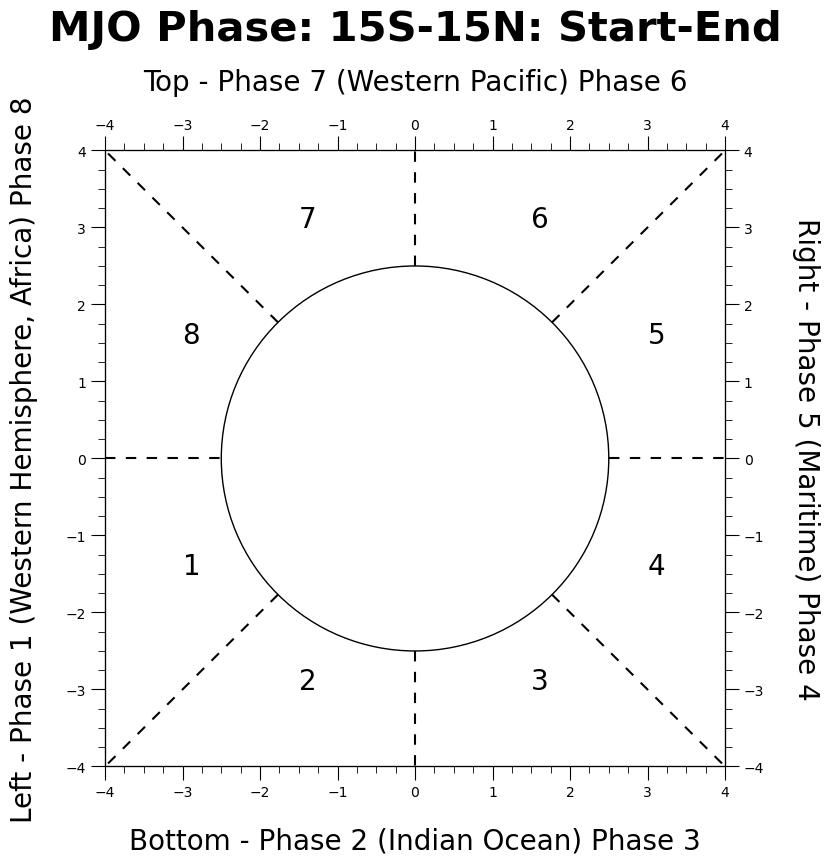

In [62]:
mjo_phase_background(is_darkmode=False, radius=2.5)

Working Example -- Phase diagram split into 8 equal parts for example:

 <p align="center">
    <img src="https://psl.noaa.gov/mjo/mjoindex/romi_cpcolr_phase_diag.png">
</p>

## Wheeler-Hendon MJO Plot
The Wheeler-Hendon MJO index plots the time, location, and magnitude/amplitude of the MJO described by the multivariate MJO index. The amplitude of the index represents the radial distance from the center. Phases are split into 8 standard MJO phases.

- ROMI: Realtime OLR (Outgoing longware radiation) MJO Index
- RMM*: Realtime Multivariate Madden-Julian Index
- OOMI: Original OLR MJO Index
- OMI: OLR (Outgoing longware radiation) MJO Index
- RMII: Realtime Multivariate Index

In [2]:
import pandas as pd

In [60]:
romi_url = "https://www.psl.noaa.gov/mjo/mjoindex/romi.cpcolr.1x.txt"
df = pd.read_csv(romi_url, sep="\s+", header=None, names=["YYYY", "MM", "DD", "HH", "RMM1", "RMM2", "Phase"])
df

,YYYY,MM,DD,HH,RMM1,RMM2,Phase
0,1991,1,1,0,0.12526,-0.06945,0.14323
1,1991,1,2,0,0.18542,-0.04887,0.19175
2,1991,1,3,0,0.23960,-0.03933,0.24281
3,1991,1,4,0,0.27446,0.01990,0.27518
4,1991,1,5,0,0.27714,0.07555,0.28725
...,...,...,...,...,...,...,...
12805,2026,1,22,0,-0.61316,-0.79638,1.00508
12806,2026,1,23,0,-0.57790,-0.83587,1.01619
12807,2026,1,24,0,-0.63295,-0.95172,1.14298
12808,2026,1,25,0,-0.79702,-1.18500,1.42810


In [57]:
df_2002 = df[df["YYYY"] == 2002]
df_2002

,YYYY,MM,DD,HH,RMM1,RMM2,Phase
4018,2002,1,1,0,0.50428,-0.40834,0.64888
4019,2002,1,2,0,0.64879,-0.40265,0.76358
4020,2002,1,3,0,0.70911,-0.38964,0.80911
4021,2002,1,4,0,0.76865,-0.40525,0.86894
4022,2002,1,5,0,0.86831,-0.49324,0.99862
...,...,...,...,...,...,...,...
4378,2002,12,27,0,0.72227,2.31739,2.42734
4379,2002,12,28,0,0.40089,2.33126,2.36547
4380,2002,12,29,0,0.13384,2.29873,2.30262
4381,2002,12,30,0,-0.18752,2.17925,2.18731


In [265]:
# Create base of the map for a Phase Diagram
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker # force integar ticks on axis
import matplotlib.lines as lines # add phase division lines
import numpy as np

def mjo_phase_background_data(is_darkmode=False,
                              data=None,
                              radius=1):
    if is_darkmode:
        plt.style.use("dark_background") # dark mode for testing
        color_dm = "white"
    else:
        plt.style.use("default")
        color_dm = "black"
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)
    
    # set x and y axis labels
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax2 = ax.twinx() 
    ax3 = ax.twiny()
    ax2.set_xlim(-4, 4)
    ax2.set_ylim(-4, 4)
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-4, 4)
    ax.set_ylabel("Phase 1 (Western Hemisphere, Africa) Phase 8", fontsize=20, labelpad=20)
    ax.set_xlabel("Phase 2 (Indian Ocean) Phase 3", fontsize=20, labelpad=20)
    ax2.set_ylabel("Phase 5 (Maritime) Phase 4", fontsize=20, labelpad=40, rotation=270)
    ax3.set_xlabel("Phase 7 (Western Pacific) Phase 6", fontsize=20, labelpad=20)
    
    # add amplitude circle
    amplitude_circle = plt.Circle((0, 0), radius, color=color_dm, fill=False)
    ax.add_patch(amplitude_circle)
    
    # add phase diagram lines
    ## Phase 1-8
    phase_line = lines.Line2D([-4, -radius],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 1-2
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 2-3
    phase_line = lines.Line2D([0, 0],
                               [-radius, -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 3-4
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 4-5
    phase_line = lines.Line2D([radius, 4],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 5-6
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 6-7
    phase_line = lines.Line2D([0, 0],
                               [radius, 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 7-8
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    
    # add tick marks
    full_tickmarks = np.arange(-4, 4.5, 0.5)
    ax.set_xticks(full_tickmarks)
    ax.set_yticks(full_tickmarks)
    # hide tickmarks for top/right axis)
    ax2.set_yticks(full_tickmarks)
    ax3.set_xticks(full_tickmarks)
    
    # add (optional) phase number text in each segment
    ax.text(-3, -1.5, "1", color=color_dm, fontsize=20)
    ax.text(-1.5, -3, "2", color=color_dm, fontsize=20)
    ax.text(1.5, -3, "3", color=color_dm, fontsize=20)
    ax.text(3, -1.5, "4", color=color_dm, fontsize=20)
    ax.text(3, 1.5, "5", color=color_dm, fontsize=20)
    ax.text(1.5, 3, "6", color=color_dm, fontsize=20)
    ax.text(-1.5, 3, "7", color=color_dm, fontsize=20)
    ax.text(-3, 1.5, "8", color=color_dm, fontsize=20)
    
    # plot whole numbers integar tick marks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    # increase length of major ticks
    ax.tick_params(which="major", length=10)
    ax2.tick_params(which="major", length=10)
    ax3.tick_params(which="major", length=10)

    # plot minor ticks every 0.25
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    # increase length of minor ticks
    ax.tick_params(which="minor", length=5)
    ax2.tick_params(which="minor", length=5)
    ax3.tick_params(which="minor", length=5)

    # plot with title
    first_index = data.iloc[0]
    start_date = f'{int(first_index["YYYY"])}-{int(first_index["MM"])}-{int(first_index["DD"])}'
    last_index = data.iloc[-1]
    end_date = f'{int(last_index["YYYY"])}-{int(last_index["MM"])}-{int(last_index["DD"])}'
    
    plt.title(f"MJO Phase: 15S-15N: {start_date} to {end_date}", fontsize=30, fontweight="bold", pad=20)

    # Plot Data
    colors = ["red", "blue", "orange", "green", "magenta", "yellow",
              "pink", "cyan", "gold", "lime", "darkviolet", "olive"]
    
    month_dict = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 
                  7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

    all_months = data["MM"].unique()
    months = [color for month_mm, color in month_dict.items() if month_mm in all_months]
    
    start_index = -3.3 + ((12 - len(months))* 0.28)

    for i, month in enumerate(months):
        if i == 0:
            # First Element
            text = ax.text(start_index, -3.5, month, color=colors[i], fontsize=13)
        else:
            # Remaining Elements
            text = ax.annotate(f"  {month}", 
                               xycoords=text, 
                               xy=(1, 0), 
                               verticalalignment="bottom",
                               fontsize=13,
                               color=colors[i])

    plt.show()

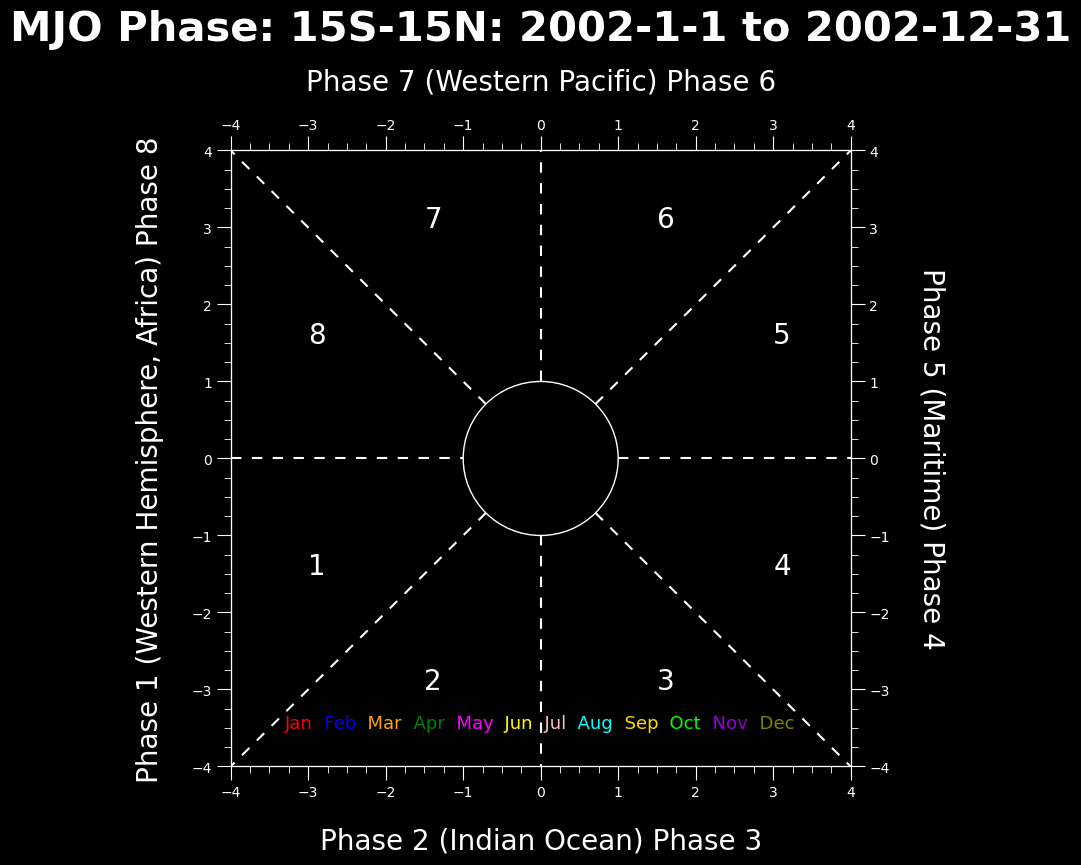

In [266]:
mjo_phase_background_data(is_darkmode=True, radius=1, data=df_2002)